# Figuras del informe

**Curso** CC2017 Modelación y Simulación · Universidad del Valle de Guatemala
**Proyecto** Simulación estocástica del forrajeo y la polinización de abejas

---

Genera las doce figuras que el informe reserva en su sección de Resultados. Cada
figura se guarda como PNG en `results/figures/` lista para insertar en el
documento, y el texto que la acompaña indica **qué mecanismo carga**, para que
ninguna quede de relleno.

Todas se construyen a partir de los resultados guardados en `results/runs/`.
Ninguna vuelve a simular, salvo las dos primeras, que ilustran los generadores
de salidas y por eso necesitan producir muestras.

In [1]:
import json, math, glob, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '../src')
from scipy import stats

from bee_sim.config import cargar
from bee_sim.analysis.campaign_io import cargar_resumenes, csvs_por_escenario
from bee_sim.generators import crear_fuente
from bee_sim.simulation.departures import generar_salidas
from bee_sim.simulation.distance import probabilidad_retorno

AMBAR, AMBAR2, AMBAR3 = '#B87813', '#D9A253', '#EBCB95'
SALVIA, TINTA, ALERTA = '#4F6B4A', '#43463C', '#A2402A'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'savefig.dpi': 200,
                     'savefig.bbox': 'tight'})

FIGS = '../results/figures'; os.makedirs(FIGS, exist_ok=True)
RAIZ = '../results/runs'
ORDEN = ['bees_low','base','bees_high','flowers_low','flowers_high',
         'distance_near','distance_far','lambda_low','lambda_high',
         'pollination_low','pollination_high','combined']
ETIQUETA = {'base':'BASE','bees_low':'ABEJAS-BAJA','bees_high':'ABEJAS-ALTA',
            'flowers_low':'FLORES-BAJA','flowers_high':'FLORES-ALTA',
            'distance_near':'DIST-CERCA','distance_far':'DIST-LEJOS',
            'lambda_low':'LAMBDA-BAJA','lambda_high':'LAMBDA-ALTA',
            'pollination_low':'POLIN-BAJA','pollination_high':'POLIN-ALTA',
            'combined':'COMBINADO'}

def guardar(fig, n, nombre):
    ruta = f'{FIGS}/fig{n:02d}_{nombre}.png'
    fig.savefig(ruta); print('guardada:', ruta.replace('../',''))

# resumenes de la campana
filas = cargar_resumenes(RAIZ, ultimos_por_escenario=500)
S = pd.DataFrame(filas)

# viajes crudos: una muestra de replicas por escenario, para las figuras que
# necesitan el detalle viaje por viaje
def viajes(esc, n=30):
    archivos = csvs_por_escenario(RAIZ, esc, ultimos=n)
    if not archivos: raise FileNotFoundError(f'no hay CSV para {esc} en {RAIZ}')
    return pd.concat([pd.read_csv(a) for a in archivos], ignore_index=True)

cfg = cargar('../config/base.yaml')
print(f'{len(S):,} resúmenes cargados')

6,000 resúmenes cargados


## Figura 1. Tiempos entre salidas

**Mecanismo:** valida el generador exponencial construido por transformada
inversa contra su densidad teórica.

guardada: results/figures/fig01_interarribos.png


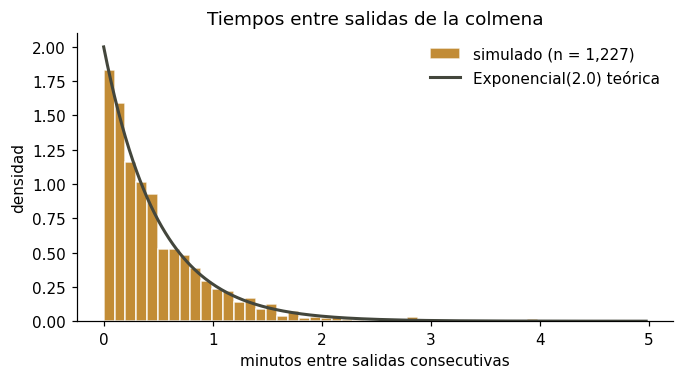

In [2]:
lam = cfg['departures']['lambda_per_min']; T = cfg['simulation']['day_minutes']
sal = generar_salidas('A', lam, T, crear_fuente('lcg', 2026))
esperas = np.diff([0] + sal)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(esperas, bins=50, density=True, color=AMBAR, edgecolor='white', alpha=.85,
        label=f'simulado (n = {len(esperas):,})')
x = np.linspace(0, esperas.max(), 300)
ax.plot(x, lam*np.exp(-lam*x), color=TINTA, lw=2, label=f'Exponencial({lam}) teórica')
ax.set_xlabel('minutos entre salidas consecutivas'); ax.set_ylabel('densidad')
ax.set_title('Tiempos entre salidas de la colmena'); ax.legend(frameon=False)
guardar(fig, 1, 'interarribos'); plt.show()

## Figura 2. Los dos métodos de generación de salidas

**Mecanismo:** muestra que el Método A (interarribos exponenciales) y el Método B
(conteo Poisson más uniformidad condicional) son dos representaciones del mismo
proceso. Si difirieran, habría un error de implementación.

guardada: results/figures/fig02_metodos_a_b.png


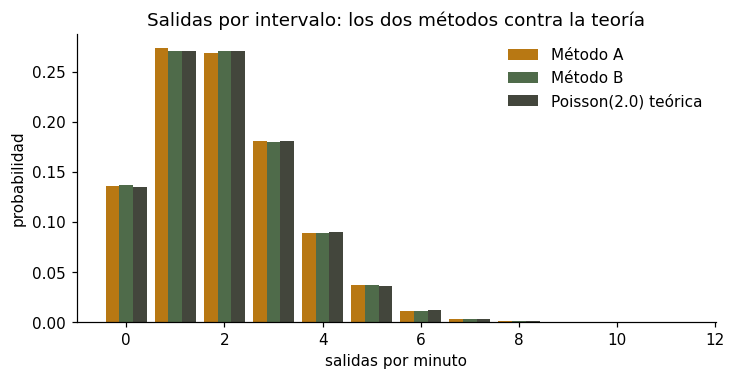

media A 1.9899 | media B 1.9960 | teórica 2.0000


In [3]:
def conteos_por_ventana(metodo, n_rep=60, ventana=1.0):
    out = []
    for s in range(n_rep):
        t = np.array(generar_salidas(metodo, lam, T, crear_fuente('lcg', 3000+s)))
        out.extend(np.histogram(t, bins=np.arange(0, T+ventana, ventana))[0])
    return np.array(out)

ca, cb = conteos_por_ventana('A'), conteos_por_ventana('B')
ks = np.arange(0, max(ca.max(), cb.max())+1)
teo = stats.poisson.pmf(ks, lam)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
w = 0.28
ax.bar(ks-w, [np.mean(ca==k) for k in ks], w, color=AMBAR, label='Método A')
ax.bar(ks,   [np.mean(cb==k) for k in ks], w, color=SALVIA, label='Método B')
ax.bar(ks+w, teo, w, color=TINTA, label=f'Poisson({lam}) teórica')
ax.set_xlabel('salidas por minuto'); ax.set_ylabel('probabilidad')
ax.set_title('Salidas por intervalo: los dos métodos contra la teoría')
ax.legend(frameon=False)
guardar(fig, 2, 'metodos_a_b'); plt.show()
print(f'media A {ca.mean():.4f} | media B {cb.mean():.4f} | teórica {lam:.4f}')

## Figura 3. Población activa

**Mecanismo: la saturación.** Es el resultado emergente del modelo. Nadie
programó una regla de saturación: aparece del choque entre la intensidad del
proceso de salidas y la capacidad de la colonia.

guardada: results/figures/fig03_poblacion_activa.png


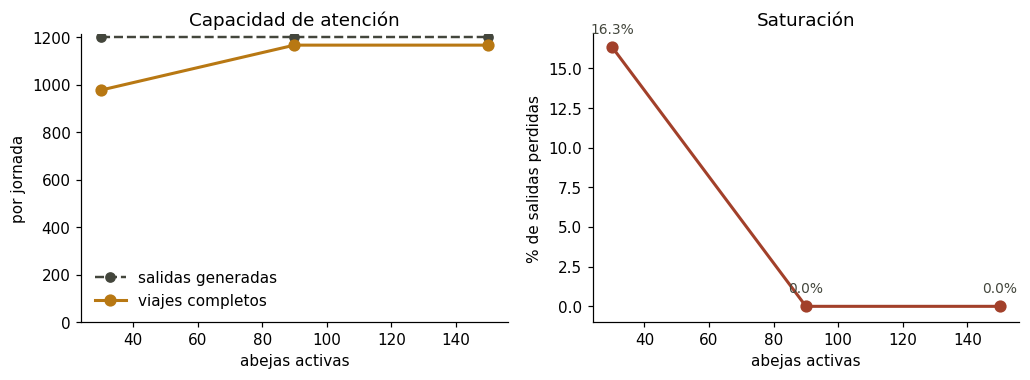

In [4]:
ab = {'bees_low':30,'base':90,'bees_high':150}
g = S[S.escenario.isin(ab)].groupby('escenario')[
        ['salidas_totales','viajes_completos','flores_polinizadas','tasa_salidas_perdidas']].mean()
g = g.reindex(['bees_low','base','bees_high']); g['abejas'] = [ab[e] for e in g.index]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(g.abejas, g.salidas_totales, 'o--', color=TINTA, lw=1.6, ms=6, label='salidas generadas')
ax[0].plot(g.abejas, g.viajes_completos, 'o-', color=AMBAR, lw=2, ms=7, label='viajes completos')
ax[0].set_xlabel('abejas activas'); ax[0].set_ylabel('por jornada')
ax[0].set_title('Capacidad de atención'); ax[0].legend(frameon=False); ax[0].set_ylim(0, None)

ax[1].plot(g.abejas, g.tasa_salidas_perdidas*100, 'o-', color=ALERTA, lw=2, ms=7)
for xi, yi in zip(g.abejas, g.tasa_salidas_perdidas*100):
    ax[1].annotate(f'{yi:.1f}%', (xi, yi), textcoords='offset points',
                   xytext=(0,9), ha='center', fontsize=9, color=TINTA)
ax[1].set_xlabel('abejas activas'); ax[1].set_ylabel('% de salidas perdidas')
ax[1].set_title('Saturación'); ax[1].set_ylim(-1, None)
guardar(fig, 3, 'poblacion_activa'); plt.show()

**Lectura.** El techo no lo pone la disponibilidad floral sino la intensidad
del proceso de salidas: con lambda fijo solo se generan unas 1,200 salidas por
jornada, así que pasar de 90 a 150 forrajeras no agrega rendimiento. Esto matiza
la hipótesis original del informe, que anticipaba el límite por flores.

## Figura 4. Flores visitadas según disponibilidad

**Mecanismo:** el nivel del parche desplaza la distribución completa, no solo su
media. Se usa el escenario BASE, donde la disponibilidad se sortea por viaje, y
se separan los tres niveles a partir de la columna registrada en cada viaje.

guardada: results/figures/fig04_flores_por_disponibilidad.png


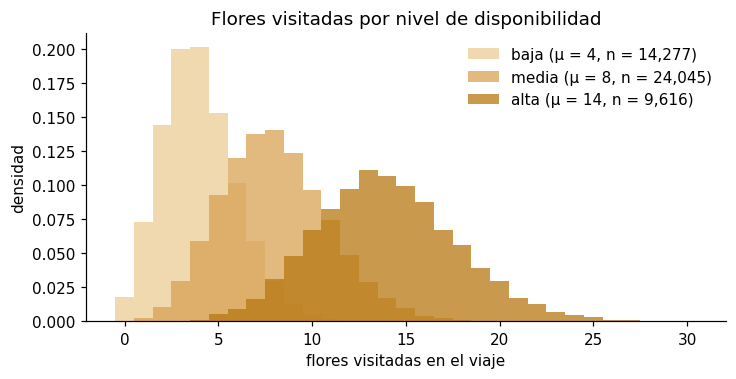

In [5]:
v = viajes('base', 40)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for niv, color in [('baja', AMBAR3), ('media', AMBAR2), ('alta', AMBAR)]:
    d = v[v.flower_availability == niv].flowers_visited
    mu = cfg['environment']['levels'][niv]['mu_flowers']
    ax.hist(d, bins=np.arange(0, 32)-.5, density=True, alpha=.75, color=color,
            label=f'{niv} (μ = {mu:.0f}, n = {len(d):,})')
ax.set_xlabel('flores visitadas en el viaje'); ax.set_ylabel('densidad')
ax.set_title('Flores visitadas por nivel de disponibilidad'); ax.legend(frameon=False)
guardar(fig, 4, 'flores_por_disponibilidad'); plt.show()

## Figura 5. Distancia contra duración del viaje

**Mecanismo:** el costo temporal de la distancia. La banda muestra la dispersión
entre viajes a la misma distancia, que viene de la búsqueda y del forrajeo.

guardada: results/figures/fig05_distancia_duracion.png


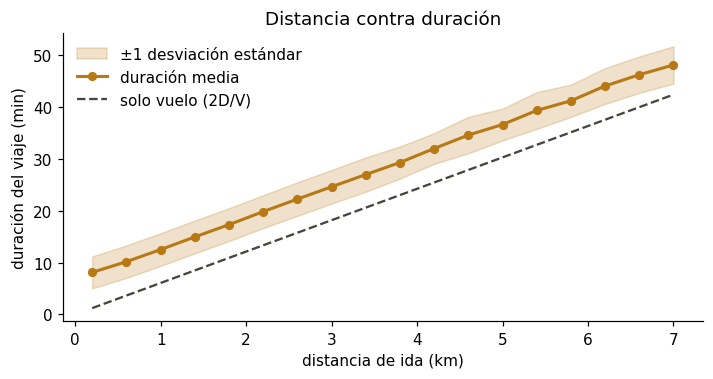

In [6]:
v = pd.concat([viajes(e, 25) for e in ('distance_near','base','distance_far')])
bins = np.arange(0, 7.5, 0.4); v['bin'] = pd.cut(v.distance_km, bins)
g = v.groupby('bin', observed=True).trip_duration_min.agg(['mean','std','count'])
g = g[g['count'] >= 30]
centros = np.array([i.mid for i in g.index])

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.fill_between(centros, g['mean']-g['std'], g['mean']+g['std'],
                color=AMBAR, alpha=.22, label='±1 desviación estándar')
ax.plot(centros, g['mean'], 'o-', color=AMBAR, lw=2, ms=5, label='duración media')
v_km = cfg['foraging']['velocity_km_min']
ax.plot(centros, 2*centros/v_km, '--', color=TINTA, lw=1.5, label='solo vuelo (2D/V)')
ax.set_xlabel('distancia de ida (km)'); ax.set_ylabel('duración del viaje (min)')
ax.set_title('Distancia contra duración'); ax.legend(frameon=False)
guardar(fig, 5, 'distancia_duracion'); plt.show()

**Lectura.** La distancia entre las dos curvas es el tiempo que la abeja pasa
en el parche, buscándolo y trabajándolo. Se mantiene aproximadamente constante,
lo que confirma que el vuelo es el único componente que escala con la distancia.

## Figura 6. Convergencia de la tasa de polinización

**Mecanismo:** la ley de los grandes números actuando sobre el ensayo Bernoulli.
Graficar visitadas contra polinizadas daría una recta sin información; lo que sí
dice algo es cómo la tasa observada converge al parámetro configurado.

guardada: results/figures/fig06_convergencia_polinizacion.png


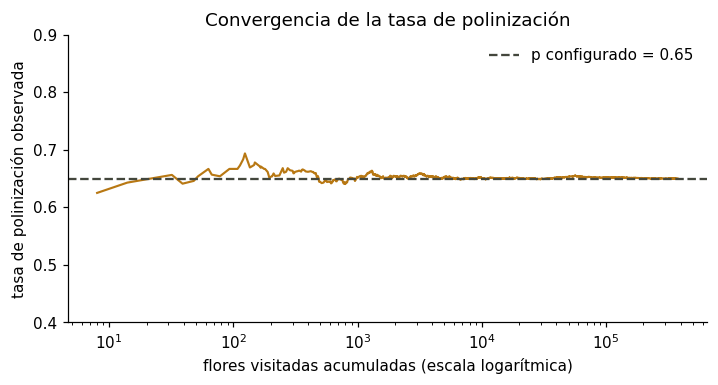

tasa final sobre 383,337 visitas: 0.6494


In [7]:
v = viajes('base', 40)
acum_vis = v.flowers_visited.cumsum(); acum_pol = v.flowers_pollinated.cumsum()
tasa = acum_pol / acum_vis
p = cfg['pollination']['p_success']

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(acum_vis, tasa, color=AMBAR, lw=1.4)
ax.axhline(p, color=TINTA, ls='--', lw=1.5, label=f'p configurado = {p}')
ax.set_xscale('log'); ax.set_ylim(0.4, 0.9)
ax.set_xlabel('flores visitadas acumuladas (escala logarítmica)')
ax.set_ylabel('tasa de polinización observada')
ax.set_title('Convergencia de la tasa de polinización'); ax.legend(frameon=False)
guardar(fig, 6, 'convergencia_polinizacion'); plt.show()
print(f'tasa final sobre {acum_vis.iloc[-1]:,} visitas: {tasa.iloc[-1]:.4f}')

## Figura 7. Eficiencia según disponibilidad y distancia

**Mecanismo:** néctar por minuto de actividad, no néctar total. El total repite
la figura de flores; la eficiencia dice algo distinto.

guardada: results/figures/fig07_eficiencia_nectar.png


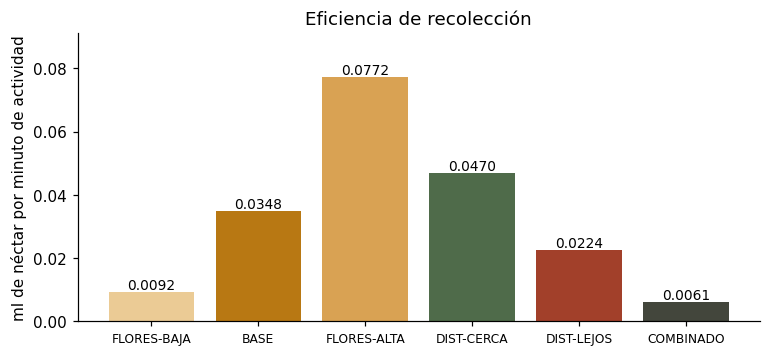

In [8]:
grupos = [('FLORES-BAJA','flowers_low'),('BASE','base'),('FLORES-ALTA','flowers_high'),
          ('DIST-CERCA','distance_near'),('DIST-LEJOS','distance_far'),('COMBINADO','combined')]
et = [g[0] for g in grupos]
val = [S[S.escenario==g[1]].nectar_por_minuto_planificado_ml.mean() for g in grupos]
col = [AMBAR3, AMBAR, AMBAR2, SALVIA, ALERTA, TINTA]

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(et, val, color=col)
for i, x in enumerate(val):
    ax.text(i, x, f'{x:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('ml de néctar por minuto de actividad')
ax.set_title('Eficiencia de recolección'); ax.tick_params(axis='x', labelsize=8)
ax.set_ylim(0, max(val)*1.18)
guardar(fig, 7, 'eficiencia_nectar'); plt.show()

## Figura 8. Distancia contra tasa de retorno

**Mecanismo:** contrasta la tasa de retorno observada viaje por viaje contra la
función logística configurada. Es la validación de que el modelo de retorno hace
lo que dice hacer.

guardada: results/figures/fig08_retorno_distancia.png


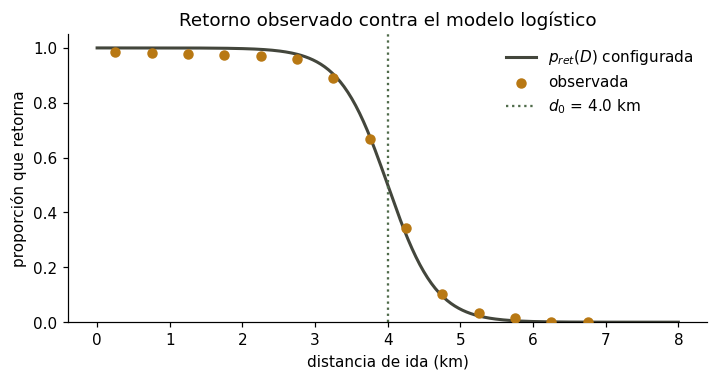

In [9]:
v = pd.concat([viajes(e, 25) for e in ('distance_near','base','distance_far')])
bins = np.arange(0, 8.5, 0.5); v['bin'] = pd.cut(v.distance_km, bins)
g = v.groupby('bin', observed=True).agg(obs=('returned','mean'), n=('returned','size'))
g = g[g.n >= 40]; centros = np.array([i.mid for i in g.index])

fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = np.linspace(0, 8, 300)
ax.plot(x, [probabilidad_retorno(d, cfg) for d in x], color=TINTA, lw=2,
        label='$p_{ret}(D)$ configurada')
ax.scatter(centros, g.obs, s=34, color=AMBAR, zorder=3, label='observada')
ax.axvline(cfg['return']['midpoint_km'], color=SALVIA, ls=':', lw=1.5,
           label=f"$d_0$ = {cfg['return']['midpoint_km']} km")
ax.set_xlabel('distancia de ida (km)'); ax.set_ylabel('proporción que retorna')
ax.set_title('Retorno observado contra el modelo logístico')
ax.set_ylim(0, 1.05); ax.legend(frameon=False)
guardar(fig, 8, 'retorno_distancia'); plt.show()

**Lectura.** Los puntos caen sobre la curva salvo en las distancias mayores,
donde quedan por debajo: ahí se suma la segunda causa de no retorno, que es el
viaje que no cabe en lo que resta de la jornada. Esa separación entre una causa
estructural y una causa supuesta es la que sostiene la interpretación.

## Figura 9. El costo de volar lejos

**Mecanismo:** la distancia no reduce la polinización por hacer peor cada viaje,
sino porque cada viaje ocupa más tiempo a la forrajera y caben menos.

guardada: results/figures/fig09_costo_distancia.png


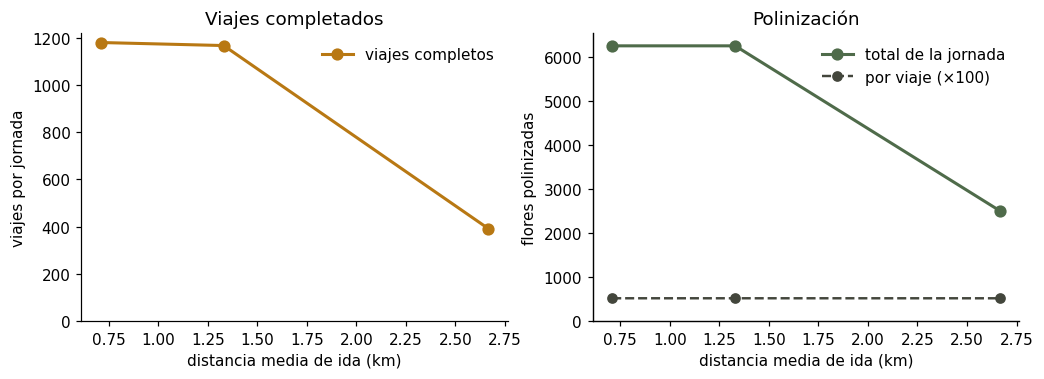

               distancia_media_ida_km  viajes_completos  flores_polinizadas_por_viaje
escenario                                                                            
distance_near                0.709361          1179.336                      5.198605
base                         1.330051          1166.470                      5.198605
distance_far                 2.664970           392.252                      5.196150


In [10]:
ds = ['distance_near','base','distance_far']
g = S[S.escenario.isin(ds)].groupby('escenario')[
        ['distancia_media_ida_km','viajes_completos','flores_polinizadas',
         'flores_polinizadas_por_viaje','duracion_media_min']].mean().reindex(ds)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(g.distancia_media_ida_km, g.viajes_completos, 'o-', color=AMBAR, lw=2, ms=7,
           label='viajes completos')
ax[0].set_xlabel('distancia media de ida (km)'); ax[0].set_ylabel('viajes por jornada')
ax[0].set_title('Viajes completados'); ax[0].set_ylim(0, None); ax[0].legend(frameon=False)

ax[1].plot(g.distancia_media_ida_km, g.flores_polinizadas, 'o-', color=SALVIA, lw=2, ms=7,
           label='total de la jornada')
ax2 = ax[1].twiny(); ax2.set_xticks([])   # eje superior vacio, solo para el segundo trazo
ax[1].plot(g.distancia_media_ida_km, g.flores_polinizadas_por_viaje*100, 'o--',
           color=TINTA, lw=1.6, ms=6, label='por viaje (×100)')
ax[1].set_xlabel('distancia media de ida (km)'); ax[1].set_ylabel('flores polinizadas')
ax[1].set_title('Polinización'); ax[1].set_ylim(0, None); ax[1].legend(frameon=False)
guardar(fig, 9, 'costo_distancia'); plt.show()
print(g[['distancia_media_ida_km','viajes_completos','flores_polinizadas_por_viaje']].to_string())

## Figura 10. Disponibilidad floral, con la duración incluida

**Mecanismo: la joroba invertida.** El nivel de disponibilidad mueve tres
parámetros a la vez, y la escala del tiempo de búsqueda va en dirección
contraria a las otras dos. El resultado es que la duración del viaje no es
monótona: el parche pobre es lento por buscar y el rico es lento por trabajar.

guardada: results/figures/fig10_disponibilidad_floral.png


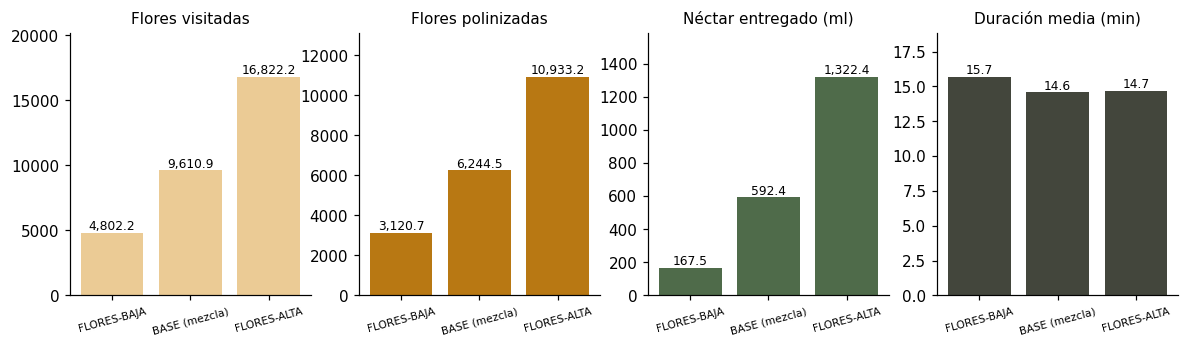

duración media por nivel:
  FLORES-BAJA       15.71 min
  BASE (mezcla)     14.58 min
  FLORES-ALTA       14.71 min


In [11]:
fs = ['flowers_low','base','flowers_high']
g = S[S.escenario.isin(fs)].groupby('escenario')[
        ['flores_visitadas','flores_polinizadas','nectar_entregado_ml',
         'duracion_media_min']].mean().reindex(fs)
et = ['FLORES-BAJA','BASE (mezcla)','FLORES-ALTA']

fig, ax = plt.subplots(1, 4, figsize=(13, 3.1))
for a, col, tit, color in [
        (ax[0],'flores_visitadas','Flores visitadas', AMBAR3),
        (ax[1],'flores_polinizadas','Flores polinizadas', AMBAR),
        (ax[2],'nectar_entregado_ml','Néctar entregado (ml)', SALVIA),
        (ax[3],'duracion_media_min','Duración media (min)', TINTA)]:
    a.bar(et, g[col], color=color)
    for i, x in enumerate(g[col]): a.text(i, x, f'{x:,.1f}', ha='center', va='bottom', fontsize=8)
    a.set_title(tit, fontsize=10); a.tick_params(axis='x', labelsize=7, rotation=15)
    a.set_ylim(0, g[col].max()*1.2)
guardar(fig, 10, 'disponibilidad_floral'); plt.show()
print('duración media por nivel:')
for e, d in zip(et, g.duracion_media_min): print(f'  {e:16} {d:6.2f} min')

## Figura 11. Comparación global normalizada

**Mecanismo:** pone los doce escenarios en una sola escala, tomando BASE como
referencia, para leer de un vistazo qué factor pesa más sobre cada métrica.

guardada: results/figures/fig11_comparacion_global.png


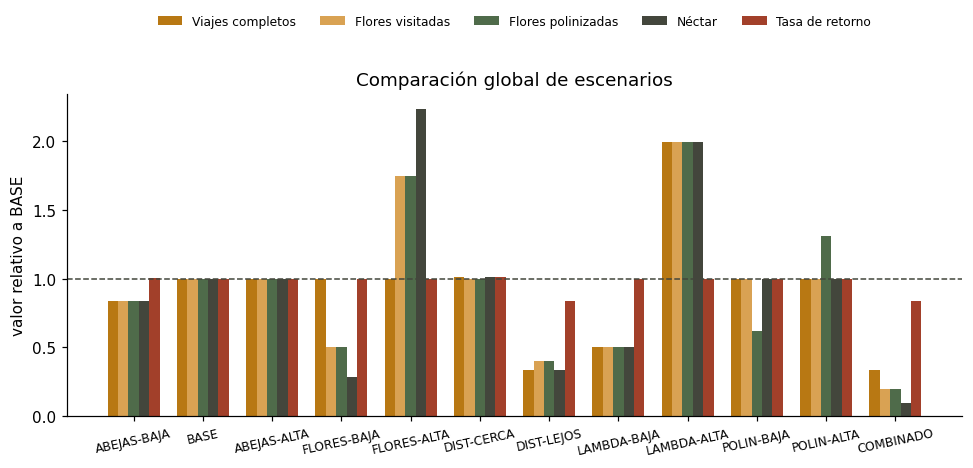

             viajes_completos  flores_visitadas  flores_polinizadas  nectar_entregado_ml  tasa_retorno
ABEJAS-BAJA             0.838             0.836               0.836                0.838         1.002
BASE                    1.000             1.000               1.000                1.000         1.000
ABEJAS-ALTA             1.000             1.000               1.000                1.000         1.000
FLORES-BAJA             0.998             0.500               0.500                0.283         0.998
FLORES-ALTA             1.000             1.750               1.751                2.232         1.000
DIST-CERCA              1.011             1.000               1.000                1.011         1.011
DIST-LEJOS              0.336             0.401               0.401                0.337         0.836
LAMBDA-BAJA             0.501             0.501               0.501                0.501         1.000
LAMBDA-ALTA             1.998             1.998               1.998      

In [12]:
MET = {'viajes_completos':'Viajes completos','flores_visitadas':'Flores visitadas',
       'flores_polinizadas':'Flores polinizadas','nectar_entregado_ml':'Néctar',
       'tasa_retorno':'Tasa de retorno'}
g = S.groupby('escenario')[list(MET)].mean().reindex(ORDEN)
norm = g / g.loc['base']
norm.index = [ETIQUETA[e] for e in norm.index]

fig, ax = plt.subplots(figsize=(10.5, 3.8))
n_met = len(MET); w = 0.15; idx = np.arange(len(norm))
colores = [AMBAR, AMBAR2, SALVIA, TINTA, ALERTA]
for j, (k, etq) in enumerate(MET.items()):
    ax.bar(idx + (j - n_met/2 + .5)*w, norm[k], w, color=colores[j], label=etq)
ax.axhline(1.0, color=TINTA, lw=1, ls='--')
ax.set_xticks(idx); ax.set_xticklabels(norm.index, fontsize=8, rotation=12)
ax.set_ylabel('valor relativo a BASE'); ax.set_title('Comparación global de escenarios')
ax.legend(frameon=False, ncol=5, fontsize=8, loc='upper center', bbox_to_anchor=(.5, 1.28))
guardar(fig, 11, 'comparacion_global'); plt.show()
print(norm.to_string(float_format=lambda v: f'{v:.3f}'))

## Figura 12. Los dos factores agregados a la matriz

**Mecanismo:** el primer panel muestra que el rendimiento escala de forma
proporcional a la intensidad de salidas, es decir que el sistema está limitado
por la demanda y no por la capacidad de la colonia en todo el rango ensayado. El
segundo muestra que la tasa de polinización observada reproduce el parámetro
configurado sin sesgo.

Es material adicional a las doce que el informe reserva.

guardada: results/figures/fig12_barridos_lambda_p.png


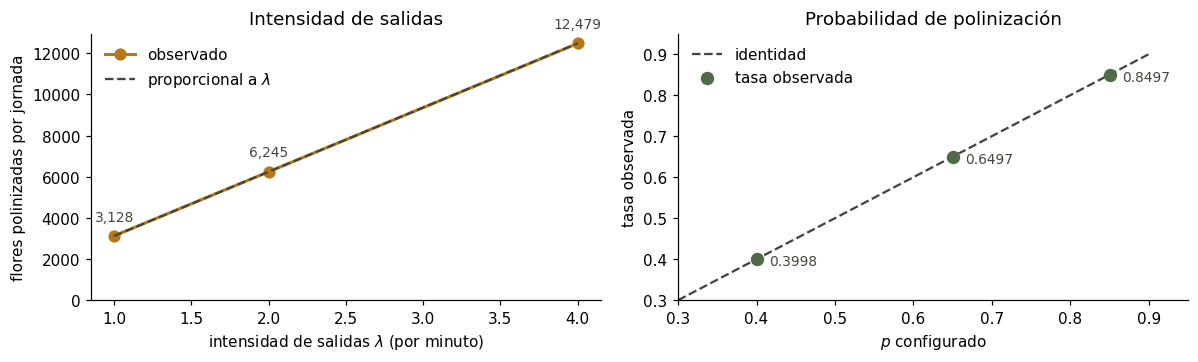

In [13]:
lam = {'lambda_low':1.0,'base':2.0,'lambda_high':4.0}
pp  = {'pollination_low':0.40,'base':0.65,'pollination_high':0.85}
gl = S[S.escenario.isin(lam)].groupby('escenario').flores_polinizadas.mean().reindex(list(lam))
gp = S[S.escenario.isin(pp)].groupby('escenario')[['tasa_polinizacion','flores_polinizadas']].mean().reindex(list(pp))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
xl = [lam[e] for e in gl.index]
ax[0].plot(xl, gl.values, 'o-', color=AMBAR, lw=2, ms=7, label='observado')
prop = gl.loc['base'] * np.array(xl) / 2.0
ax[0].plot(xl, prop, '--', color=TINTA, lw=1.5, label='proporcional a $\lambda$')
for x_, y_ in zip(xl, gl.values):
    ax[0].annotate(f'{y_:,.0f}', (x_, y_), textcoords='offset points',
                   xytext=(0,10), ha='center', fontsize=9, color=TINTA)
ax[0].set_xlabel('intensidad de salidas $\lambda$ (por minuto)')
ax[0].set_ylabel('flores polinizadas por jornada')
ax[0].set_title('Intensidad de salidas'); ax[0].legend(frameon=False); ax[0].set_ylim(0, None)

xp = [pp[e] for e in gp.index]
ax[1].plot([0.3, 0.9], [0.3, 0.9], '--', color=TINTA, lw=1.5, label='identidad')
ax[1].scatter(xp, gp.tasa_polinizacion, s=60, color=SALVIA, zorder=3, label='tasa observada')
for x_, y_ in zip(xp, gp.tasa_polinizacion):
    ax[1].annotate(f'{y_:.4f}', (x_, y_), textcoords='offset points',
                   xytext=(8,-4), fontsize=9, color=TINTA)
ax[1].set_xlabel('$p$ configurado'); ax[1].set_ylabel('tasa observada')
ax[1].set_title('Probabilidad de polinización'); ax[1].legend(frameon=False)
ax[1].set_xlim(0.3, 0.95); ax[1].set_ylim(0.3, 0.95)
plt.tight_layout(); guardar(fig, 12, 'barridos_lambda_p'); plt.show()

---

## Resumen

Las doce figuras quedaron guardadas en `results/figures/` a 200 dpi, listas para
insertarse en el informe. Cada una carga un mecanismo del modelo y no solo una
distribución: la saturación en la 3, la joroba invertida de la duración en la
10, la separación de las dos causas de no retorno en la 8, y la convergencia al
parámetro configurado en la 6.

Todas se regeneran ejecutando este documento contra los resultados guardados,
sin volver a correr la simulación.